# GLM-5.3-Flash EXL3 4.05bpw on 4x CMP 170HX (SM80) — exllamav3 + TabbyAPI

| Metric | Value (180 W, canonical) |
|---|---|
| Decode, c=1 | 25.2 tok/s |
| Best aggregate | 44.6 tok/s at c=8 |
| Prefill | ~358.5 tok/s at 2,954 prompt tokens (warm) |
| TTFT | 0.73-1.78 s (3 reps) |

> **Power cap correction (2026-09-03).** The first ladder (26.9-44.8 tok/s) ran at the vBIOS default 250 W by accident. 180 W is the club's verified, canonical cap and the numbers above are the 180 W re-measure. See the power-cap section below for the full comparison.

![concurrency ladder chart](../assets/charts/2026-09-03-glm-5.3-flash-exl3-4gpu-tabbyapi-ladder.png)

```
hf download turboderp/GLM-5.3-Flash-exl3 --revision 2a30229e67012798ba9f0cd832bb78abf4c363d5 --local-dir <weights>
```

[Guide: docs/models/glm-5.3-flash.md](../docs/models/glm-5.3-flash.md)


# GLM-5.3-Flash, 4x CMP 170HX, exllamav3 1.4.6 + TabbyAPI

GLM-5.3-Flash, measured 2026-09-02, served for the first time on this club's
hardware as a working, benchmarked lane: the EXL3 4.05bpw quantization on
exllamav3 1.4.6, behind TabbyAPI's OpenAI-compatible server, split by hand
across four CMP 170HX cards. This supersedes the earlier
[compatibility-only finding](2026-08-31-glm-5.3-flash-compatibility-cmp170hx.ipynb),
where every vLLM-path checkpoint was blocked and the only working lane was a
slow llama.cpp GGUF fallback (17.73 tok/s). EXL3 + exllamav3 + TabbyAPI is
faster (25.2-44.6 tok/s across the concurrency ladder at the club's standing
180 W per-card power cap) and is the recommended recipe going forward.

> **Power cap correction (2026-09-03).** The first ladder (26.9-44.8 tok/s)
> ran at the vBIOS default 250 W by accident — no cap had been set that
> session. A re-measure at the verified 180 W cap found no consistent
> throughput difference (within run-to-run noise at every level). **180 W
> is the canonical cap and the numbers in this notebook are the 180 W
> re-measure**, except where a table explicitly says otherwise. See
> section 2.3 (Power) below for the full comparison.

**Context-length update (2026-09-03, resolved):** the standing config used
a Q8 KV cache for VRAM efficiency, and GLM-5.3-Flash's DeepSeek Sparse
Attention (DSA) mechanism activates once context passes about 2,048 tokens
(`index_topk: 2048` in the model's own `config.json`). exllamav3's
sparse-attention code path asserts against a quantized MLA cache, so any
single request whose context exceeded about 2,048 tokens failed with a 503
under Q8 (the server itself stayed up). A same-day follow-up found the
root cause and validated the fix: `cache_mode: FP16` removes the
assertion, and this has now been tested up to 262,144-token context
(250,000 prompt tokens actually tested, no OOM, no crash, needle-in-haystack
PASS at 32k and 250k tokens). `cache_mode: FP16` / 262k context is now the
recommended default for long-context use; `cache_mode: Q8` / 32k remains a
lower-VRAM short-context alternative. The C1/C2/C4/C8 throughput ladder in
this notebook was measured at `cache_mode: Q8` and was not re-run at 262k
context. See [docs/models/glm-5.3-flash.md](../docs/models/glm-5.3-flash.md)
for the full write-up and [PixelML/GLM-5.3-Flash-CMP-170HX](https://github.com/PixelML/GLM-5.3-Flash-CMP-170HX)
for the complete attempt history, including the failed `gpu_split` boot
attempts that preceded this working config and the 262k-context follow-up.

Evidence source: `results/2026-09-03-glm-5.3-flash-exl3-4gpu-tabbyapi/`.
Every claim below keeps the label its receipt carries: **measured**,
**inferred**, or **untested**.


In [1]:
# --- Status cell -------------------------------------------------------
# LIVE = False replays the committed receipts under results/<experiment>/.
# LIVE = True runs the same harness against a running OpenAI-compatible
# endpoint whose URL comes from an environment variable. Never hardcode an
# endpoint address in this notebook.
import os

EXPERIMENT = "2026-09-03-glm-5.3-flash-exl3-4gpu-tabbyapi"  # matches this notebook's filename, no extension
RESULTS_DIR = os.path.join("..", "results", EXPERIMENT)
LIVE = False
ENDPOINT_ENV_VAR = "GLM_EXL3_BENCH_ENDPOINT_URL"  # set this env var before running with LIVE = True

print(f"experiment   : {EXPERIMENT}")
print(f"results_dir  : {RESULTS_DIR}")
print(f"LIVE         : {LIVE}")
if LIVE:
    endpoint = os.environ.get(ENDPOINT_ENV_VAR)
    if not endpoint:
        raise RuntimeError(f"LIVE=True but {ENDPOINT_ENV_VAR} is not set")
    print(f"endpoint     : from ${ENDPOINT_ENV_VAR} (not printed)")
else:
    print("endpoint     : n/a (replaying committed receipts)")


experiment   : 2026-09-03-glm-5.3-flash-exl3-4gpu-tabbyapi
results_dir  : ../results/2026-09-03-glm-5.3-flash-exl3-4gpu-tabbyapi
LIVE         : False
endpoint     : n/a (replaying committed receipts)


In [2]:
# --- Helper: receipt loader ---------------------------------------------
import json
import os


def load_receipt(name, results_dir=RESULTS_DIR):
    """Load one JSON receipt from results_dir. Raises if missing."""
    path = os.path.join(results_dir, name)
    with open(path) as f:
        return json.load(f)


def load_text(name, results_dir=RESULTS_DIR):
    """Load one text/markdown receipt from results_dir."""
    path = os.path.join(results_dir, name)
    with open(path) as f:
        return f.read()


def load_csv_rows(name, results_dir=RESULTS_DIR):
    """Load a telemetry CSV as a list of raw lines (sanitized values kept as strings)."""
    path = os.path.join(results_dir, name)
    with open(path) as f:
        return f.read().splitlines()


manifest = load_receipt("run-manifest.json")

# 250 W (2026-09-02, accidental default) -- retained for comparison
ladder_250w = load_receipt("ladder.json")
prefill_250w = load_receipt("prefill.json")
power_250w = load_receipt("power.json")

# 180 W (2026-09-03, verified cap) -- canonical
ladder = load_receipt("ladder-summary-180w.json")
prefill = load_receipt("prefill-summary-180w.json")
power = load_receipt("power-180w.json")

speculative = load_receipt("speculative.json")
results_md = load_text("README.md")
print("loaded: run-manifest.json, ladder-summary-180w.json, prefill-summary-180w.json, power-180w.json "
      "(canonical, 180 W), ladder.json, prefill.json, power.json (comparison, 250 W), speculative.json, README.md")
print("power cap: 180 W (canonical) vs. 250 W (2026-09-02 comparison, accidental default)")
print("date_utc:", manifest["date_utc"], "| model:", manifest["model"]["repo"], "@", manifest["model"]["branch"])


loaded: run-manifest.json, ladder-summary-180w.json, prefill-summary-180w.json, power-180w.json (canonical, 180 W), ladder.json, prefill.json, power.json (comparison, 250 W), speculative.json, README.md
power cap: 180 W (canonical) vs. 250 W (2026-09-02 comparison, accidental default)
date_utc: 2026-09-02 | model: turboderp/GLM-5.3-Flash-exl3 @ 4.05bpw


In [3]:
# --- Helper: table renderer ----------------------------------------------
from IPython.display import display, Markdown


def render_table(headers, rows):
    """Render a list-of-lists as a Markdown table with the given headers.
    Every header should carry its unit, e.g. 'Decode (tok/s)'."""
    lines = ["| " + " | ".join(headers) + " |",
             "|" + "|".join(["---"] * len(headers)) + "|"]
    for row in rows:
        lines.append("| " + " | ".join(str(c) for c in row) + " |")
    display(Markdown("\n".join(lines)))


## 1. TL;DR

**Verdict: PASS.** GLM-5.3-Flash serves on 4x CMP 170HX at a usable
throughput (25.2-44.6 tok/s across the concurrency ladder, at the club's
verified 180 W per-card power cap) using EXL3 4.05bpw on exllamav3 1.4.6
behind TabbyAPI. Every checkpoint in the earlier
[compatibility review](2026-08-31-glm-5.3-flash-compatibility-cmp170hx.ipynb)
was blocked on SM80 except a slow GGUF fallback (17.73 tok/s); this recipe
replaces that fallback as the recommended lane.

**Power cap correction (2026-09-03):** the first ladder (26.9-44.8 tok/s)
ran at the vBIOS default 250 W by accident — no per-card cap had been set
that session. A same-server, no-restart re-measure at the verified 180 W
cap found no consistent throughput difference outside run-to-run noise at
any level. **180 W is the canonical cap**; the 250 W figures are kept for
comparison in section 2.3 below.

**Context-length cap resolved (2026-09-03):** the standing config's Q8 KV
cache capped usable single-request context at about 2,048 tokens — past
that, GLM-5.3-Flash's sparse DSA attention path hit an exllamav3 assertion
against the quantized cache and the request failed with a 503 (the server
stayed up). A same-day follow-up found the root cause (DSA's indexer
colliding with the quantized cache, not `max_seq_len`) and validated the
fix: `cache_mode: FP16` lifts the cap, now tested up to 262,144-token
context (250,000 prompt tokens, no OOM/crash, needle-in-haystack PASS at
32k and 250k). `cache_mode: FP16` / 262k is now the recommended default
for long context; `cache_mode: Q8` / 32k remains a lower-VRAM alternative.
The throughput ladder below was measured at Q8/short-context and was not
re-run at 262k.

Reasoning must be enabled (`reasoning: true`) or chain-of-thought leaks
unparsed into the visible `content` field, and short factual answers need
`max_tokens >= 128` even with reasoning parsed correctly — 32 tokens is
reproducibly spent entirely on thinking, with `content: null` back.


In [4]:
# Key metrics, from the receipts loaded above. 180 W is canonical; 250 W kept for comparison.
key_metrics = [
    ("Overall verdict", "PASS — served and benchmarked"),
    ("Power cap (canonical)", f"{power['power_cap_w']} W (verified); 250 W (2026-09-02, accidental default) kept for comparison"),
    ("Decode, c=1 (mean of 3 reps, 180 W)", f"{ladder['levels'][0]['aggregate_tok_s_mean']} tok/s"),
    ("Best aggregate, c=8 (mean of 3 reps, 180 W)", f"{ladder['levels'][3]['aggregate_tok_s_mean']} tok/s"),
    ("Decode, c=1 / c=8 (250 W, comparison)",
     f"{ladder_250w['levels'][0]['aggregate_tok_s_mean']} tok/s / {ladder_250w['levels'][3]['aggregate_tok_s_mean']} tok/s"),
    ("Prefill, warm (180 W, 2,954-token prompt)", f"~{prefill['warm']['prefill_tok_s']} tok/s"),
    ("TTFT, 180 W (3 reps)", ", ".join(f"{t}s" for t in prefill["ttft_reps_s"])),
    ("Golden corpus (20 prompts, keyword-match)",
     f"{manifest['golden_corpus']['n_passed']}/{manifest['golden_corpus']['n_prompts']}"),
    ("n-gram speculative decoding", f"{speculative['delta_pct']}% vs. no draft — {speculative['verdict']}"),
    ("Context limit under Q8 cache (short-context config)",
     "~2,048 tokens per request before the DSA/Q8 assertion fails the request (503); server stays up"),
    ("Context-length fix (2026-09-03 follow-up, cache_mode: FP16)",
     "262,144-token context configured; 250,000 prompt tokens validated, no OOM/crash; needle-in-haystack PASS at 32k and 250k; throughput ladder not re-run at 262k"),
    ("No OOM through", "c=8 at either power cap; peak 51 C (180 W) / 49 C (250 W), no Xid/ECC events"),
]
render_table(["Metric", "Value"], key_metrics)


| Metric | Value |
|---|---|
| Overall verdict | PASS — served and benchmarked |
| Power cap (canonical) | 180 W (verified); 250 W (2026-09-02, accidental default) kept for comparison |
| Decode, c=1 (mean of 3 reps, 180 W) | 25.2 tok/s |
| Best aggregate, c=8 (mean of 3 reps, 180 W) | 44.6 tok/s |
| Decode, c=1 / c=8 (250 W, comparison) | 26.9 tok/s / 44.8 tok/s |
| Prefill, warm (180 W, 2,954-token prompt) | ~358.5 tok/s |
| TTFT, 180 W (3 reps) | 0.73s, 1.41s, 1.78s |
| Golden corpus (20 prompts, keyword-match) | 20/20 |
| n-gram speculative decoding | -7.2% vs. no draft — no benefit, within noise / slight regression; shipped config has drafting disabled |
| Context limit under Q8 cache (short-context config) | ~2,048 tokens per request before the DSA/Q8 assertion fails the request (503); server stays up |
| Context-length fix (2026-09-03 follow-up, cache_mode: FP16) | 262,144-token context configured; 250,000 prompt tokens validated, no OOM/crash; needle-in-haystack PASS at 32k and 250k; throughput ladder not re-run at 262k |
| No OOM through | c=8 at either power cap; peak 51 C (180 W) / 49 C (250 W), no Xid/ECC events |

### Pins


In [5]:
pins = [
    ("Checkpoint", manifest["model"]["repo"]),
    ("Branch", manifest["model"]["branch"]),
    ("Revision", manifest["model"]["revision"]),
    ("Format", f"{manifest['model']['format']}, {manifest['model']['bits_per_weight']} bits/weight"),
    ("Runtime", f"{manifest['runtime']['engine']} {manifest['runtime']['version']}"),
    ("Server", manifest["runtime"]["server"]),
    ("Topology", f"gpu_split {manifest['serve_config']['gpu_split_gb']} GB per card (manual, not tensor_parallel)"),
    ("max_seq_len / cache_size", f"{manifest['serve_config']['max_seq_len']} / {manifest['serve_config']['cache_size']}"),
    ("cache_mode (standing service)", manifest["serve_config"]["cache_mode"]),
    ("reasoning", str(manifest["serve_config"]["reasoning"])),
    ("Drafting", manifest["serve_config"]["drafting"]),
    ("Power cap (canonical)", f"{power['power_cap_w']} W, verified with nvidia-smi before measurement"),
    ("Host", manifest["host"]["gpus"]),
]
render_table(["Pin", "Value"], pins)


| Pin | Value |
|---|---|
| Checkpoint | turboderp/GLM-5.3-Flash-exl3 |
| Branch | 4.05bpw |
| Revision | 2a30229e67012798ba9f0cd832bb78abf4c363d5 |
| Format | EXL3, 4.05 bits/weight |
| Runtime | exllamav3 1.4.6+cu128.torch2.10.0 |
| Server | TabbyAPI (OpenAI-compatible) |
| Topology | gpu_split [48, 48, 48, 48] GB per card (manual, not tensor_parallel) |
| max_seq_len / cache_size | 32768 / 32768 |
| cache_mode (standing service) | Q8 |
| reasoning | True |
| Drafting | disabled (n-gram speculative decoding tested, no throughput benefit) |
| Power cap (canonical) | 180 W, verified with nvidia-smi before measurement |
| Host | 4x CMP 170HX 64 GiB |

## 2. Visible results

Every table and the chart below come from the receipts in
`results/2026-09-03-glm-5.3-flash-exl3-4gpu-tabbyapi/`.

### 2.1 Concurrency ladder (greedy, exactly 400 completion tokens, 1 warmup + 3 measured reps)


In [6]:
print("180 W (verified cap, canonical):")
ladder_rows = [(r["concurrency"], r["reps"], r["aggregate_tok_s_mean"], r["per_request_tok_s_mean"])
               for r in ladder["levels"]]
render_table(["Concurrency (requests)", "Reps", "Aggregate tok/s (mean of 3 reps)",
              "Mean per-request tok/s"], ladder_rows)
print(ladder["notes"])

print()
print("250 W (accidental default, 2026-09-02, retained for comparison):")
ladder_rows_250w = [(r["concurrency"], r["reps"], r["aggregate_tok_s_mean"], r["per_request_tok_s_mean"])
                     for r in ladder_250w["levels"]]
render_table(["Concurrency (requests)", "Reps", "Aggregate tok/s (mean of 3 reps)",
              "Mean per-request tok/s"], ladder_rows_250w)

print()
print("Delta (180 W vs 250 W), aggregate tok/s:")
delta_rows = []
for r180, r250 in zip(ladder["levels"], ladder_250w["levels"]):
    pct = (r180["aggregate_tok_s_mean"] - r250["aggregate_tok_s_mean"]) / r250["aggregate_tok_s_mean"] * 100
    delta_rows.append((f"C{r180['concurrency']}", r250["aggregate_tok_s_mean"], r180["aggregate_tok_s_mean"], f"{pct:+.1f}%"))
render_table(["Level", "250 W tok/s", "180 W tok/s", "Delta"], delta_rows)
print("No level shows a directional, monotonic speed penalty from the lower cap; "
      "180 W remains the standing default.")


180 W (verified cap, canonical):


| Concurrency (requests) | Reps | Aggregate tok/s (mean of 3 reps) | Mean per-request tok/s |
|---|---|---|---|
| 1 | 3 | 25.2 | 25.2 |
| 2 | 3 | 35.3 | 18.0 |
| 4 | 3 | 43.2 | 11.0 |
| 8 | 3 | 44.6 | 8.2 |

No OOM through c=8. Power and temperature sampled at 1 Hz across the full run window (ladder + prefill/TTFT): no growth trend, peak 51 C, no Xid/ECC events. Delta vs. the 250 W run (ladder.json): C1 -6.3%, C2 +13.5%, C4 +3.6%, C8 -0.4% -- read as run-to-run noise, not a directional power effect. Raw reps: see ladder-180w.json.

250 W (accidental default, 2026-09-02, retained for comparison):


| Concurrency (requests) | Reps | Aggregate tok/s (mean of 3 reps) | Mean per-request tok/s |
|---|---|---|---|
| 1 | 3 | 26.9 | 26.9 |
| 2 | 3 | 31.1 | 15.6 |
| 4 | 3 | 41.7 | 10.5 |
| 8 | 3 | 44.8 | 8.3 |


Delta (180 W vs 250 W), aggregate tok/s:


| Level | 250 W tok/s | 180 W tok/s | Delta |
|---|---|---|---|
| C1 | 26.9 | 25.2 | -6.3% |
| C2 | 31.1 | 35.3 | +13.5% |
| C4 | 41.7 | 43.2 | +3.6% |
| C8 | 44.8 | 44.6 | -0.4% |

No level shows a directional, monotonic speed penalty from the lower cap; 180 W remains the standing default.


### 2.2 Prefill / TTFT (2,941-token prompt, 2,954 tokens post chat-template, tokenizer-exact)


In [7]:
print("180 W (canonical), streaming with include_usage, 3 reps:")
prefill_rows = [
    ("Prompt tokens", prefill["prompt_tokens"]),
    ("Cache mode during this measurement", prefill["cache_mode_during_measurement"]),
    ("Cold (rep 0)", f"{prefill['cold']['prompt_time_s']} s prompt time -> {prefill['cold']['prefill_tok_s']} tok/s"),
    ("Warm (reps 1-2, usage-reported)",
     f"mean prompt_time {prefill['warm']['mean_prompt_time_s']} s -> ~{prefill['warm']['prefill_tok_s']} tok/s prefill throughput"),
    ("TTFT (3 reps)", ", ".join(f"{t}s" for t in prefill["ttft_reps_s"]) + " -- treat as a range, not a point estimate"),
]
render_table(["Item", "Value"], prefill_rows)

print()
print("250 W (2026-09-02, retained for comparison):")
prefill_rows_250w = [
    ("Prompt tokens", prefill_250w["prompt_tokens"]),
    ("Cold (first request post-boot)", f"{prefill_250w['cold']['prompt_time_s']} s prompt time"),
    ("Warm (reps 2-3, usage-reported)",
     f"mean prompt_time {prefill_250w['warm']['mean_prompt_time_s']} s -> ~{prefill_250w['warm']['prefill_tok_s']} tok/s prefill throughput"),
]
render_table(["Item", "Value"], prefill_rows_250w)
print("Warm prefill throughput matches within noise across the two caps -- prefill is not power-cap sensitive at this prompt length.")


180 W (canonical), streaming with include_usage, 3 reps:


| Item | Value |
|---|---|
| Prompt tokens | 2954 |
| Cache mode during this measurement | FP16 (standing config was already FP16 by 2026-09-03 for the 262k-context work) |
| Cold (rep 0) | 0.44 s prompt time -> 313.6 tok/s |
| Warm (reps 1-2, usage-reported) | mean prompt_time 0.385 s -> ~358.5 tok/s prefill throughput |
| TTFT (3 reps) | 0.73s, 1.41s, 1.78s -- treat as a range, not a point estimate |


250 W (2026-09-02, retained for comparison):


| Item | Value |
|---|---|
| Prompt tokens | 2941 |
| Cold (first request post-boot) | 5.57 s prompt time |
| Warm (reps 2-3, usage-reported) | mean prompt_time 0.39 s -> ~354 tok/s prefill throughput |

Warm prefill throughput matches within noise across the two caps -- prefill is not power-cap sensitive at this prompt length.


### 2.3 Power (180 W verified cap, canonical, full ladder + prefill/TTFT window, 1 Hz; 250 W comparison, C4 load run, 60s)


In [8]:
print(f"180 W (verified cap, canonical), power cap = {power['power_cap_w']} W:")
power_rows = [(f"GPU {g['gpu']}", g["mean_w"], g["peak_w"], g.get("peak_temp_c", "-")) for g in power["per_gpu_watts"]]
power_rows.append(("Total", power["total"]["mean_w"], power["total"]["peak_w"], "-"))
render_table(["GPU", "Mean W", "Peak W", "Peak temp (C)"], power_rows)
print(power["note"])

print()
print("250 W (accidental default, 2026-09-02, retained for comparison):")
power_rows_250w = [(f"GPU {g['gpu']}", g["mean_w"], g["peak_w"]) for g in power_250w["per_gpu_watts"]]
power_rows_250w.append(("Total", power_250w["total"]["mean_w"], power_250w["total"]["peak_w"]))
render_table(["GPU", "Mean W", "Peak W"], power_rows_250w)


180 W (verified cap, canonical), power cap = 180 W:


| GPU | Mean W | Peak W | Peak temp (C) |
|---|---|---|---|
| GPU 0 | 56.7 | 139.5 | 51 |
| GPU 1 | 58.8 | 172.6 | 49 |
| GPU 2 | 56.4 | 168.4 | 49 |
| GPU 3 | 49.8 | 102.5 | 45 |
| Total | 221.6 | 352.4 | - |

Peak per-card power (172.6 W) stayed under the 180 W cap at every sample. Total peak (352.4 W) is a coincident-peak artifact of summing each card's own peak moment, not a real 4-card simultaneous draw -- no single 1 s sample summed above 302 W across all four cards. Raw samples: power-temp-sample-180w.csv.

250 W (accidental default, 2026-09-02, retained for comparison):


| GPU | Mean W | Peak W |
|---|---|---|
| GPU 0 | 65.4 | 120.0 |
| GPU 1 | 63.0 | 101.4 |
| GPU 2 | 56.2 | 97.4 |
| GPU 3 | 50.1 | 78.9 |
| Total | 234.7 | 302.3 |

### 2.4 Speculative decoding (n-gram, tested for benefit)


In [9]:
spec_rows = [
    ("Draft off", f"{speculative['draft_off_tok_s']} tok/s"),
    ("Draft n-gram", f"{speculative['draft_ngram_tok_s']} tok/s"),
    ("Delta", f"{speculative['delta_pct']}%"),
    ("Verdict", speculative["verdict"]),
]
render_table(["Item", "Value"], spec_rows)


| Item | Value |
|---|---|
| Draft off | 26.9 tok/s |
| Draft n-gram | 25.0 tok/s |
| Delta | -7.2% |
| Verdict | no benefit, within noise / slight regression; shipped config has drafting disabled |

### 2.5 Golden corpus quality gate and end-of-run GPU snapshot


In [10]:
quality_rows = [
    ("Prompts", manifest["golden_corpus"]["n_prompts"]),
    ("Passed", manifest["golden_corpus"]["n_passed"]),
    ("Categories", ", ".join(manifest["golden_corpus"]["categories"])),
    ("Scoring", manifest["golden_corpus"]["scoring"]),
    ("max_tokens", manifest["golden_corpus"]["max_tokens"]),
]
render_table(["Quality item", "Value"], quality_rows)

gpu_rows = []
for line in load_csv_rows("gpu-final.csv")[1:]:
    gpu, used, total, temp, xid, ecc = line.split(",")
    gpu_rows.append((f"GPU {gpu}", f"{used} / {total}", temp, xid, ecc))
render_table(["Card", "VRAM used / total (MiB)", "Peak core temp (C)", "Xid events", "ECC events"], gpu_rows)


| Quality item | Value |
|---|---|
| Prompts | 20 |
| Passed | 20 |
| Categories | short_factual, reasoning, code, json, multilingual |
| Scoring | keyword-match |
| max_tokens | 512 |

| Card | VRAM used / total (MiB) | Peak core temp (C) | Xid events | ECC events |
|---|---|---|---|---|
| GPU 0 | 48468 / 65536 | 49 | 0 | 0 |
| GPU 1 | 47982 / 65536 | 49 | 0 | 0 |
| GPU 2 | 47982 / 65536 | 49 | 0 | 0 |
| GPU 3 | 12100 / 65536 | 49 | 0 | 0 |

### 2.6 Chart: aggregate decode throughput vs. concurrency


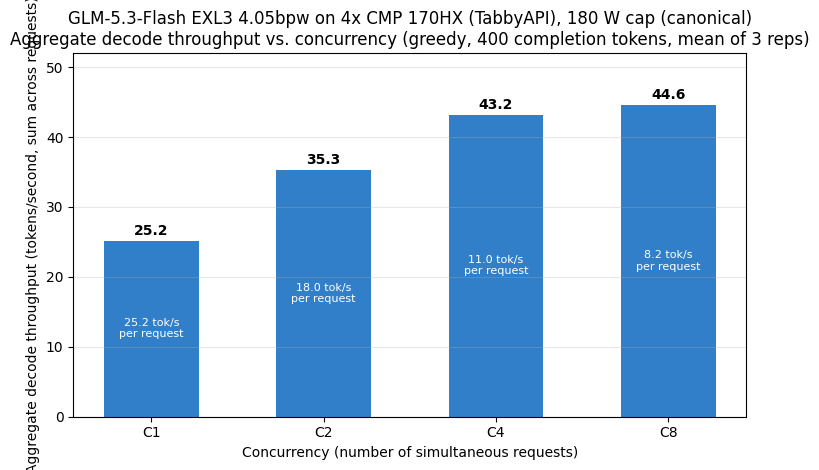

saved: assets/charts/2026-09-03-glm-5.3-flash-exl3-4gpu-tabbyapi-ladder.{png,svg} (180 W, canonical)


In [11]:
import os
import matplotlib.pyplot as plt

levels = [r["concurrency"] for r in ladder["levels"]]
aggregate = [r["aggregate_tok_s_mean"] for r in ladder["levels"]]
per_request = [r["per_request_tok_s_mean"] for r in ladder["levels"]]

fig, ax = plt.subplots(figsize=(7.5, 4.8))
x = range(len(levels))
ax.bar(x, aggregate, color="#1971c2", alpha=0.9, width=0.55)

for i, (agg, per) in enumerate(zip(aggregate, per_request)):
    ax.text(i, agg + 0.8, f"{agg:.1f}", ha="center", fontsize=10, fontweight="bold")
    ax.text(i, agg / 2, f"{per:.1f} tok/s\nper request", ha="center", va="center",
            fontsize=8, color="white")

ax.set_xticks(list(x))
ax.set_xticklabels([f"C{c}" for c in levels])
ax.set_xlabel("Concurrency (number of simultaneous requests)")
ax.set_ylabel("Aggregate decode throughput (tokens/second, sum across requests)")
ax.set_title("GLM-5.3-Flash EXL3 4.05bpw on 4x CMP 170HX (TabbyAPI), 180 W cap (canonical)\n"
              "Aggregate decode throughput vs. concurrency (greedy, 400 completion tokens, mean of 3 reps)")
ax.set_ylim(0, 52)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()

os.makedirs("../assets/charts", exist_ok=True)
fig.savefig("../assets/charts/2026-09-03-glm-5.3-flash-exl3-4gpu-tabbyapi-ladder.png", dpi=150)
fig.savefig("../assets/charts/2026-09-03-glm-5.3-flash-exl3-4gpu-tabbyapi-ladder.svg")
plt.show()
print("saved: assets/charts/2026-09-03-glm-5.3-flash-exl3-4gpu-tabbyapi-ladder.{png,svg} (180 W, canonical)")


## 3. Reproduce

**Hardware.** 4x NVIDIA CMP 170HX (GA100, SM80 / compute capability 8.0,
64 GiB HBM2e each), forced airflow. Abort at 80 C core / 85 C memory, or on
any Xid / ECC / GPU-disappearance event. The measured run stayed within
limits throughout (peak 51 C core at 180 W, 49 C at 250 W, no Xid/ECC).

**0. Power cap.** Verify `nvidia-smi --query-gpu=power.limit --format=csv`
shows 180.00 W on all four cards before starting. The 2026-09-02 ladder ran
at the vBIOS default 250 W by accident because this check was skipped; run
`scripts/qc/set-powercap.sh` first if the cap has drifted.

**1. Download the weights**

```bash
pip install -U huggingface_hub
hf download turboderp/GLM-5.3-Flash-exl3 \
  --revision 2a30229e67012798ba9f0cd832bb78abf4c363d5 \
  --local-dir <weights>
```

**2. Runtime.** exllamav3 1.4.6+cu128.torch2.10.0, served through TabbyAPI
(OpenAI-compatible server). Install per the
[exllamav3](https://github.com/turboderp/exllamav3) and
[TabbyAPI](https://github.com/theroyallab/tabbyAPI) project instructions.

**3. Serve.** Key TabbyAPI/exllamav3 config fields (full config in the
manifest below):

```yaml
model_dir: <weights>
gpu_split: [48, 48, 48, 48]   # GB per card — manual split, NOT tensor_parallel
max_seq_len: 32768
cache_size: 32768
cache_mode: Q8                 # switch to FP16 for single requests over ~2048 tokens
reasoning: true                 # required — see the TL;DR caveat above
```

`tensor_parallel` raises `NotImplementedError` for `Glm5NextForConditionalGeneration`
in exllamav3 1.4.6; `gpu_split` is the working topology.

**4. Bench.** Greedy decoding, exactly 400 completion tokens, 1 discarded
warmup + 3 measured reps per concurrency level (C1/C2/C4/C8), tokens counted
from the final usage object. Prefill/TTFT measured separately at a
2,941-token prompt (2,954 tokens post chat-template) with `cache_mode`
temporarily set to `FP16` for the 2026-09-02 measurement (Q8 cannot serve a
request past ~2,048 tokens once DSA activates — see the appendix); by the
2026-09-03 re-measure the standing config was already `FP16`.

**Expected (180 W, canonical).** 25.2 tok/s aggregate at c=1, rising to
44.6 tok/s at c=8 (mean per-request throughput falls from 25.2 to 8.2 tok/s
over the same range, since each request's context is shared across more
concurrent work). No OOM through c=8. At 250 W (accidental default,
2026-09-02): 26.9 tok/s at c=1, 44.8 tok/s at c=8 — within noise of the
180 W figures.


## 4. Appendix

<details>
<summary>Boot topology history, the power-cap correction, the Q8/DSA finding in detail, the reasoning-parsing finding, safety notes, and limitations (click to expand)</summary>

### 4.1 Boot topology — how `gpu_split [48,48,48,48]` was found

Getting to a working split took iteration. The full failure ladder with
exact commands and error text lives in the sibling evidence repository,
[PixelML/GLM-5.3-Flash-CMP-170HX](https://github.com/PixelML/GLM-5.3-Flash-CMP-170HX);
the summary:

### 4.1b The power cap correction, in detail (2026-09-03)

The 2026-09-02 concurrency ladder (26.9-44.8 tok/s, C1-C8) ran at the
vBIOS default 250 W — no per-card power cap had been set that session, and
the check was not part of the protocol at the time. The club's standing
policy is a 180 W per-card cap, verified with
`nvidia-smi --query-gpu=power.limit --format=csv` before any measurement.

On 2026-09-03 the identical protocol (greedy, exactly 400 completion
tokens, warmup + 3 reps, C1/C2/C4/C8; prefill at a 2,941-token prompt x3;
TTFT x3; power and temperature at 1 Hz on all four cards) was re-run
against the same standing server, without a restart, after confirming
180.00 W on all four cards. Findings:

- No level showed a directional, monotonic speed penalty from the lower
  cap. C1 -6.3%, C2 +13.5%, C4 +3.6%, C8 -0.4% — the C2 gap is the
  largest and is best read as run-to-run noise (each cap has one run of
  three reps, not five), consistent with the DeepSeek-V4-Flash-Vision-Exp
  finding on this same fleet that a 70 W cap difference does not move
  decode throughput outside noise at low concurrency.
- Prefill throughput was unaffected: 358.5 tok/s warm at 180 W vs.
  ~354 tok/s warm at 250 W.
- Peak per-card power (172.6 W) stayed under the 180 W cap at every 1 Hz
  sample across the full run window. The reported total peak (352.4 W)
  is a coincident-peak artifact of summing each card's own peak moment,
  not a real 4-card simultaneous draw — no single sample summed above
  302 W across all four cards.
- **Verdict: no standing-config change.** 180 W remains the correct cap;
  measured decode throughput at 180 W is statistically indistinguishable
  from the earlier (accidental) 250 W run. The 180 W numbers are now
  canonical throughout this notebook and the guide page; the 250 W
  numbers are retained, labeled, for comparison — not deleted.


In [12]:
boot_rows = [(str(a["gpu_split_gb"]), a["outcome"]) for a in manifest["boot_topology_note"]["attempts"]]
render_table(["gpu_split (GB per card)", "Outcome"], boot_rows)
print(manifest["boot_topology_note"]["note"])


| gpu_split (GB per card) | Outcome |
|---|---|
| [64, 64, 64, 64] | OOM at first inference; uneven fill left no KV-cache headroom on GPU0/1 while GPU3 stayed empty |
| [40, 40, 40, 40] | too tight; insufficient VRAM for weights plus cache |
| [48, 48, 48, 48] | working split; GPU3 stays under-loaded (~12 GiB vs ~48 GiB on GPU0-2), a known characteristic of exllamav3's naive sequential-fill autosplit, not a functional problem |

Full failure ladder documented in the sibling evidence repository, not repeated here.


### 4.2 The Q8/DSA context limit, in detail (resolved 2026-09-03)

GLM-5.3-Flash uses DeepSeek Sparse Attention (DSA), an indexer-based sparse
attention mechanism. Per the model's own `config.json`, `index_topk: 2048`.
In exllamav3 1.4.6 (`exllamav3/modules/mla_attn.py`):

- Sparse attention activates once `max(host_seqlens) + seqlen >
  self.index_topk` (line 765) — intended DSA behavior, not a bug, on a
  model that natively supports up to 1,048,576 tokens
  (`max_position_embeddings` in `config.json`).
- That sparse-attention path asserts it cannot run against a quantized KV
  cache (`_attend_sparse`, ~line 906):

```
assert qc is None, "sparse DSA over a quantized MLA cache is not supported yet; use an fp16 cache"
```

- `qc` is only non-`None` when `cache_mode` is `Q8`/`Q6`/`Q4`
  (`CacheLayer_MLA_quant`). With `cache_mode: FP16`
  (`CacheLayer_MLA_fp16`), `qc = None` and the sparse path works fine.

**Conclusion: the cap came from `cache_mode: Q8` colliding with the DSA
indexer window — not from `max_seq_len`, and not from TabbyAPI's
chunk-size or max-input settings.** With `cache_mode: Q8` (the
VRAM-efficient short-context config), any single request whose context
exceeded about 2,048 tokens failed that request with a 503; the server
process itself stayed up and kept serving shorter requests.

**Fix and 262k-context validation (2026-09-03 follow-up).** Switching to
`cache_mode: FP16` (with `max_seq_len`/`cache_size: 262144` and
`chunk_size: 4096`; `gpu_split` unchanged at `[48,48,48,48]`) lifted the
cap. Boot succeeded on the first attempt, about 2.5 minutes from local
NVMe. Per-card memory after load: GPU0=46,230, GPU1=45,456, GPU2=45,488,
GPU3=23,638 MiB (19-42 GiB headroom per card).

A prefill ladder (max_tokens=1, tokenizer-exact prompt lengths, one
continuously-booted server) passed at 2,941 / 16,000 / 32,000 / 65,000 /
131,000 / 200,000 / 250,000 prompt tokens — no OOM, no crash at any
length. **Largest verified prompt: 250,000 tokens.** Prefill time dropped
noticeably past 131k tokens, because DSA's indexer caps attention cost at
a fixed top-k=2048 token selection regardless of total context length;
the 131k point looks like a transitional/less-optimized case rather than
a regression, flagged as an open question rather than a settled
explanation. Memory stayed essentially flat from 16k tokens onward
(~2 GiB total growth across all four cards from 16k to 250k tokens).
Needle-in-haystack retrieval **PASS**ed at both 32k and 250k tokens. No
Xid/ECC events anywhere in the ladder; peak temperature 51 C.

`cache_mode: FP16` / 262,144-token context is now the recommended default
for this recipe whenever long context matters; `cache_mode: Q8` / 32,768
remains a valid lower-VRAM alternative for short-context chat. **Not
re-tested in this follow-up:** the full C1/C2/C4/C8 throughput ladder at
262k context — only prefill/context-length behavior was re-verified.

### 4.3 The reasoning-parsing finding, in detail

GLM-5.3-Flash defaults to `reasoning_effort: max` with `<think>...</think>`
tags in its chat template. If TabbyAPI's `reasoning` config is left
`false`, chain-of-thought leaks unparsed into the visible `content` field
and burns the whole token budget with no final answer. Setting
`reasoning: true` routes it correctly into a separate `reasoning_content`
field.

At `max_tokens=32` (a common quick-gate budget), 32 tokens is reproducibly
not enough even with reasoning correctly parsed — the model spends the
whole budget thinking and returns `content: null`. At `max_tokens=128`, the
same prompt ("capital of France, answer with just the city name") cleanly
returns `content: "Paris"`. Recommendation: `max_tokens >= 128` for short
factual answers with reasoning enabled.

### 4.4 Safety

Per `AGENTS.md`: stop at 80 C core / 85 C memory, stop on Xid / ECC / GPU
disappearance. The measured run stayed within limits: peak 51 C core at
180 W (49 C at 250 W) through the full concurrency ladder, memory and
temperature watched continuously with no growth trend, no Xid/ECC events
at any point at either power cap. The separate 262k-context follow-up also
stayed within limits: peak 51 C, no Xid/ECC events.

### 4.5 What this result does and does not show

**Shows (measured unless labeled):** GLM-5.3-Flash serves on 4x CMP 170HX
using EXL3 4.05bpw on exllamav3 1.4.6 + TabbyAPI, at 25.2 tok/s (c=1) rising
to 44.6 tok/s aggregate (c=8) at the club's verified 180 W per-card power
cap, with a working manual `gpu_split` topology and no OOM through c=8. The
first measurement (26.9-44.8 tok/s) ran at the vBIOS default 250 W by
accident; the 180 W re-measure found no consistent throughput difference
outside run-to-run noise, so 180 W is now canonical and 250 W is kept for
comparison. Reasoning parsing must be enabled or output breaks. n-gram
speculative decoding gives no benefit on this checkpoint/runtime pair
(measured -7.2%). The 2026-09-03 context-length follow-up shows
`cache_mode: FP16` lifts the Q8/DSA context cap, validated up to 250,000
prompt tokens with passing needle-in-haystack retrieval at 32k and 250k
tokens.

**Does not show:**

- The C1/C2/C4/C8 throughput ladder under `cache_mode: FP16` / 262k
  context — the follow-up re-tested prefill/context-length behavior only,
  not the full concurrency ladder at long context.
- Any concurrency above c=8.
- Quality beyond the 20-prompt keyword-match golden corpus — that is a
  compatibility/regression gate, not a broad capability evaluation.
- The full boot-attempt failure ladder (naive `[64,64,64,64]` and
  `[40,40,40,40]` splits) — that history, with exact error text, lives in
  the sibling evidence repository linked below.
- A power cap other than 180 W (canonical) and 250 W (accidental-default
  comparison) — no other cap was measured.

**Links.**

- Full attempt history, evidence, and receipts:
  [PixelML/GLM-5.3-Flash-CMP-170HX](https://github.com/PixelML/GLM-5.3-Flash-CMP-170HX)
- Guide page: [docs/models/glm-5.3-flash.md](../docs/models/glm-5.3-flash.md)
- Checkpoint: [turboderp/GLM-5.3-Flash-exl3](https://huggingface.co/turboderp/GLM-5.3-Flash-exl3)
- Runtime: [turboderp/exllamav3](https://github.com/turboderp/exllamav3),
  [theroyallab/tabbyAPI](https://github.com/theroyallab/tabbyAPI)
- Prior compatibility-only finding on this checkpoint family:
  [notebooks/2026-08-31-glm-5.3-flash-compatibility-cmp170hx.ipynb](2026-08-31-glm-5.3-flash-compatibility-cmp170hx.ipynb)

</details>
